In [ ]:
# A carrier object has an ID and dictionaries with all Vehicles and all Services
class Carrier:  
    """
    This class represents a Carrier with an ID and dictionaries with all Vehicles and all Services.
    """
        
    def __init__(self, carrierID): 
        self.carrierID = carrierID 
        self.vehicles = {} 
        self.services = {}   
        self.missedDeliveries = []
        self.logisticProvider = getProviderFromID(self.carrierID)
        
    def __str__(self):
        return "[Carrier ID: " + str(self.carrierID) + " with " + str(len(self.vehicles)) + " Vehicles and " + str(len(self.services)) + " Services]"
    
    def __repr__(self):
        return self.__str__()
    
    def getNumberOfVehicles(self):
        return (len(self.vehicles))
    
    def getNumberOfServices(self):
        return (len(self.services))
        
    def addVehicle(self, vehicle): 
        self.vehicles[vehicle.getVehicleId] = vehicle
        
    def addService(self, service): 
        self.services[service.getServiceID] = service

    def getTotalNumberofServices(self):  
        return sum((s.getDemand() for s in self.services.values()))
    
    def getProvider(self):
        return self.logisticProvider
    
    def getServices(self): 
        return [s for s in self.services.values()]   
    
    def getCarrierId(self): 
        return self.carrierID    
    
    def getVehicles(self): 
        return self.vehicles
    
    def getMissedDeliveries(self): 
        return self.missedDeliveries  
    
    def setMissedDeliveries(self, missDeliveries): 
        self.missedDeliveries = missDeliveries


# A Vehicle has an ID, a Typ and you can add Plans to this vehicles with services and Routes. 
# These Vehicles / Plans have to be converted to Sumo! 
class Vehicle: 
    """
    This class represents a Vehicle with an ID, a Type and you can add Plans to this vehicles with services and Routes.
    """
        
    def __init__(self, vehicleID, vehicleType): 
        self.vehicleID = vehicleID 
        self.vehicleType = vehicleType 
        self.plans = []
        
    def __str__(self):
        return "[Vehicle ID: " + str(self.vehicleID) + " with Type: " + self.vehicleType +"]"
    
    def __repr__(self):
        return self.__str__()
    
    def addVehiclePlan(self, plan): 
        self.plans.append(plan)
        
    def changeVehicleType(self, vehicleType): 
        self.vehicleType == vehicleType
        
    def getVehicleId(self): 
        return self.vehicleID
    
    def getPlans(self):
        return self.plans


# A Plan is a sequence of Activies (start, service, service, ... , end)
# all important Information are stored in the activities / legs dictionary
# The Order of the sequence is stored as a list called "planSequence"
class Plan:  
    """
    This class represents a Plan which is a sequence of Activities (start, service, service, ... , end).
    """
        
    def __init__(self, planId, vehicle, activities, legs): 
        self.planId = planId
        self.vehicle = vehicle
        self.activities = activities 
        self.legs = legs 
        self.planSequence = [] 
        
    def __str__(self):
        return "[Plan ID: " + str(self.planId) + " with " + str(len(self.activities)) +" Activities and " + str(len(self.legs)) + " Legs]"
    
    def __repr__(self):
        return self.__str__()
    
    def getPlanSequence(self):
        return self.planSequence
    
    def createInternalPlanSequence(self):
        for i in range (len(self.legs)):            
            self.planSequence.append(get_nth_key(self.activities, i))
            self.planSequence.append(get_nth_key(self.legs, i))
        self.planSequence.append(get_nth_key(self.activities, len(self.activities)-1))    

# A Service is a data container storing all available information from the CSV/XML
class Service:
    """
    Data container for a delivery/pickup service.
    All durations are stored in seconds (int).
    Extra attributes are kept in a dict.
    """

    def __init__(self, serviceType, serviceID, capacityDemand, duration, link, extra_attributes=None):
        self.serviceType = serviceType
        self.serviceID = serviceID
        self.capacityDemand = capacityDemand
        # ensure duration is numeric seconds
        try:
            self.duration = int(duration)
        except Exception:
            self.duration = 0
        self.link = link
        self.extra_attributes = extra_attributes or {}

        # optional: vehicleType placeholder if you need it later
        self.vehicleType = self.extra_attributes.get("vehicleType", None)

    def __str__(self):
        return f"[Service ID: {self.serviceID} (Type: {self.serviceType}) with a CapacityDemand of {self.capacityDemand} to Link: {self.link}]"

    __repr__ = __str__

    # --- attributes API ---
    def getAttribute(self, key, default=None):
        return self.extra_attributes.get(key, default)

    def setAttribute(self, key, value):
        self.extra_attributes[key] = value

    # --- typed getters/setters ---
    def getServiceType(self):
        return self.serviceType

    def changeVehicleType(self, vehicleType):
        # was '==' before (no effect). Should assign.
        self.vehicleType = vehicleType
        self.extra_attributes["vehicleType"] = vehicleType

    def getDemand(self):
        return self.capacityDemand

    def getServiceID(self):
        return self.serviceID

    def getServiceLink(self):
        return self.link

    def setServiceLink(self, link):
        self.link = link

    def getDuration(self):
        """Return dwell time in seconds."""
        return int(self.duration)

    def setDuration(self, duration_s):
        """Set dwell time in seconds."""
        self.duration = int(duration_s)
        
        
        
# Get Logistic Provider from XML ID
def getProviderFromID(carrierID):
    """
    This function returns the provider name based on the carrier ID.
    
    Args:
        carrierID (str): The ID of the carrier.
        
    Returns:
        str: The name of the provider.
    """
        
    if("dhl" in str(carrierID)):
        return "dhl"  
    elif("amazon" in str(carrierID)):
        return "amazon"  
    elif("ups" in str(carrierID)):
        return "ups"  
    elif("gls" in str(carrierID)):
        return "gls"  
    elif("dpd" in str(carrierID)):
        return "dpd"  
    elif("fedex" in str(carrierID)):
        return "fedex"  
    elif("hermes" in str(carrierID)):
        return "hermes"  
    elif("wl" in str(carrierID)):
        return "White-Label"  
    else:
        raise ValueError('Carrier Provider unknown: ' + str(carrierID))
    
# Method returning the index of an element of a dictionary
def get_nth_key(dictionary, n=0):
    """
    This function returns the nth key of a dictionary.
    
    Args:
        dictionary (dict): The dictionary to get the key from.
        n (int): The index of the key to get. Default is 0.
        
    Returns:
        key: The nth key of the dictionary.
    """
        
    if n < 0:
        n += len(dictionary)
    for i, key in enumerate(dictionary.keys()):
        if i == n:
            return key
    raise IndexError("dictionary index out of range") 

In [2]:
import os
import re
import pickle
import pandas as pd

# --- Paths ---
BATCH_DIR = r"C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch"
OUTPUT_BASE = os.path.join(BATCH_DIR, r"processed")

# --- Helper to load pickles ---
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# Only files like <run>_emissions_result.pkl
PATTERN = re.compile(r"^(?P<run>.+)_result\.pkl$", re.ASCII)

def load_all_operating_result(output_base):
    """
    Returns:
      results_by_run: dict run_name -> object loaded from pickle
      df_all: DataFrame concatenated across runs if each is a DataFrame
              otherwise None
    """
    results_by_run = {}
    frames = []

    for root, _, files in os.walk(output_base):
        for fn in files:
            m = PATTERN.match(fn)
            if not m:
                continue
            run_name = m.group("run")
            p = os.path.join(root, fn)
            try:
                obj = load_pickle(p)
            except Exception as e:
                print(f"[WARN] Could not load {p}: {e}")
                continue

            results_by_run[run_name] = obj

            # If the object is a DataFrame, collect for concatenation
            if isinstance(obj, pd.DataFrame):
                df = obj.copy()
                if "run_name" not in df.columns:
                    df["run_name"] = run_name
                frames.append(df)

    df_all = pd.concat(frames, ignore_index=True) if frames else None
    print(f"[INFO] Loaded emissions_result for {len(results_by_run)} runs from {output_base}")
    if df_all is not None:
        print("[INFO] Concatenated DataFrame shape:", df_all.shape)
    return results_by_run, df_all

# --- Execute load ---
results_by_run, df_all = load_all_operating_result(OUTPUT_BASE)

# Example: inspect keys and one sample
print("Runs:", list(results_by_run.keys())[:10])

# If you want just the combined table:
if df_all is not None:
    display(df_all.head())
    
df_all[df_all["Vehicle Utilization (%)"] > 0.05]

df_all["Cost per Parcel [€/parcel]"] =  df_all["vehicle_cost"] / df_all["deliveries"] 

mapping = {
    "dhl": "Mixed",
    "gls": "Mixed",
    "dpd": "Mixed",
    "hermes": "B2C",
    "amazon": "B2C",
    "fedex": "B2B",
    "tnt": "B2B",
    "ups": "B2B",
    "fxt": "B2B",   # optional: falls du fxt nutzt
}

df_all["carrier_category"] = df_all["provider"].map(mapping).fillna("Mixed")


[INFO] Loaded emissions_result for 48 runs from C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed
[INFO] Concatenated DataFrame shape: (119073, 62)
Runs: ['basecase_12052025_iter150_jsprit100', 'basecase_13052025_iter150_jsprit100', 'basecase_14052025_iter150_jsprit100', 'basecase_15052025_iter150_jsprit100', 'basecase_16052025_iter150_jsprit100', 'basecase_17052025_iter150_jsprit100', 'batchhigh_12052025_iter150_jsprit100', 'batchhigh_13052025_iter150_jsprit100', 'batchhigh_14052025_iter150_jsprit100', 'batchhigh_15052025_iter150_jsprit100']


,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,run_name,Tour Duration,Travel Duration,tour_km,initial_delivery_distance,vehicle_load_factor,is_van,is_ev,emissions,main_area_type_name
0,freight_fedex_31832_veh_cep_size_m_7_1,24139.0,72066.0,13.313056,18233.0,8.248333,1970-01-01 06:42:19,1970-01-01 20:01:06,1970-01-01 13:18:47,1970-01-01 05:03:53,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,freight_gls_31535_veh_cep_size_l_7_1,24722.0,64152.0,10.952778,10584.0,8.012778,1970-01-01 06:52:02,1970-01-01 17:49:12,1970-01-01 10:57:10,1970-01-01 02:56:24,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,freight_ups_31311_veh_cep_size_m_7_1,25075.0,69743.0,12.407778,14136.0,8.481111,1970-01-01 06:57:55,1970-01-01 19:22:23,1970-01-01 12:24:28,1970-01-01 03:55:36,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,freight_ups_31832_veh_cep_size_m_7_1,25101.0,72941.0,13.288889,17985.0,8.293056,1970-01-01 06:58:21,1970-01-01 20:15:41,1970-01-01 13:17:20,1970-01-01 04:59:45,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,freight_gls_31535_veh_cep_size_m_7_5,25208.0,63241.0,10.564722,11392.0,7.400278,1970-01-01 07:00:08,1970-01-01 17:34:01,1970-01-01 10:33:53,1970-01-01 03:09:52,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_21052\254380589.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_run = (work.groupby(['scenario','weekday','run_name'], dropna=False)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_21052\254380589.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_cpp = (per_run.groupby(['scenario','weekday'], as_index=False)['cost_per_parcel_day']


[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\avg_cost_per_parcel_by_weekday.csv


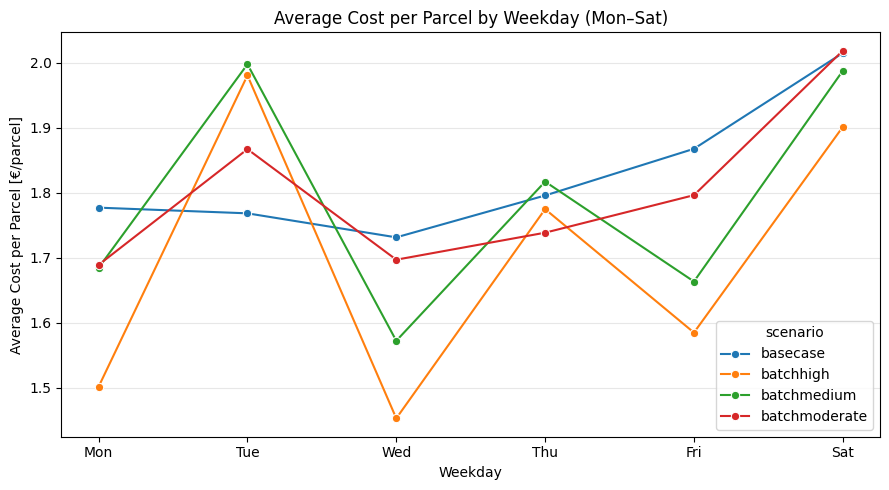

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_avg_cost_per_parcel_by_weekday.png


In [4]:
# Average Cost per Parcel by Weekday (Mon–Sat), differentiated by scenario
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preconditions
if 'df_all' not in globals() or df_all is None or len(df_all) == 0:
    raise RuntimeError("df_all is empty or not loaded. Run the loader cell above.")

work = df_all.copy()

# Ensure needed numeric columns
for col in ['vehicle_cost', 'deliveries']:
    if col not in work.columns:
        raise RuntimeError(f"Required column '{col}' missing in df_all.")
work['vehicle_cost'] = pd.to_numeric(work['vehicle_cost'], errors='coerce').fillna(0.0)
work['deliveries'] = pd.to_numeric(work['deliveries'], errors='coerce').fillna(0.0)

# If not already present, compute per-row cost per parcel (not used directly in agg, but handy)
cpp_col = 'Cost per Parcel [€/parcel]'
if cpp_col not in work.columns:
    # Avoid division by zero; will aggregate using totals below
    with np.errstate(divide='ignore', invalid='ignore'):
        work[cpp_col] = np.where(work['deliveries'] > 0, work['vehicle_cost'] / work['deliveries'], np.nan)

# Scenario from run_name prefix
if 'run_name' not in work.columns:
    raise RuntimeError("'run_name' missing in df_all; ensure loader added it.")
work['scenario'] = work['run_name'].str.split('_').str[0]

# Day token and weekday
import datetime as _dt

def _extract_day(run):
    parts = str(run).split('_')
    return parts[1] if len(parts) >= 3 and parts[1].isdigit() and len(parts[1]) == 8 else None

work['day_token'] = work['run_name'].map(_extract_day)

weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

def _weekday_label(day_token):
    try:
        d = _dt.datetime.strptime(day_token, '%d%m%Y').date()
        return ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][d.weekday()]
    except Exception:
        return None

work['weekday'] = work['day_token'].map(_weekday_label)
work = work[work['weekday'].isin(weekday_order)].copy()
work['weekday'] = pd.Categorical(work['weekday'], categories=weekday_order, ordered=True)

# Aggregate to daily (per run) totals, then compute daily cost-per-parcel
per_run = (work.groupby(['scenario','weekday','run_name'], dropna=False)
             .agg(total_cost=('vehicle_cost','sum'), total_deliveries=('deliveries','sum'))
             .reset_index())
per_run['cost_per_parcel_day'] = np.where(per_run['total_deliveries'] > 0,
                                          per_run['total_cost'] / per_run['total_deliveries'],
                                          np.nan)

# Now average across runs for the same scenario x weekday
avg_cpp = (per_run.groupby(['scenario','weekday'], as_index=False)['cost_per_parcel_day']
                 .mean())

# Persist CSV
out_csv = os.path.join(OUTPUT_BASE, 'avg_cost_per_parcel_by_weekday.csv')
avg_cpp.to_csv(out_csv, index=False)
print(f"[OK] Saved {out_csv}")

# Plot: single combined line chart (scenarios as lines)
plt.figure(figsize=(9,5))
sns.lineplot(data=avg_cpp.sort_values(['scenario','weekday']),
             x='weekday', y='cost_per_parcel_day', hue='scenario', marker='o')
plt.title('Average Cost per Parcel by Weekday (Mon–Sat)')
plt.ylabel('Average Cost per Parcel [€/parcel]')
plt.xlabel('Weekday')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
fig_path = os.path.join(OUTPUT_BASE, 'plot_avg_cost_per_parcel_by_weekday.png')
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"[OK] Saved {fig_path}")

In [14]:
# =============================================================================
# Stacked bars: daily vehicle (tour) counts per scenario, split Non-batch/Batch
# + cumulative total tours per scenario (second y-axis, synced ticks)
# =============================================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib.patches import Patch

# ---------- 1) Prepare df (wie im Distanz-Plot) ----------
work = df_all.copy()

# scenario
if "scenario" not in work.columns:
    if "run_name" not in work.columns:
        raise RuntimeError("run_name missing; cannot derive scenario")
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]

# Force weekday from run_name like "..._12052025_iter150_..."
digits = work["run_name"].astype(str).str.extract(r"(\d{8})", expand=False)

# Parse as ddmmyyyy and build weekday index 0..6
dates = pd.to_datetime(digits, format="%d%m%Y", errors="coerce")
dow = dates.dt.dayofweek  # Monday 0 ... Sunday 6

# Map to German weekday names
weekday_map = {0:"Montag", 1:"Dienstag", 2:"Mittwoch", 3:"Donnerstag", 4:"Freitag", 5:"Samstag"}
work["weekday"] = dow.map(weekday_map)

weekday_order  = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
weekday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat"]
work["weekday"] = pd.Categorical(work["weekday"], categories=weekday_order, ordered=True)


# activity_group (Batch-Day vs Non-batch-Day)
if "activity_group" not in work.columns:
    provider_active_days = {
        "dhl": {"Montag","Mittwoch","Freitag"},
        "hermes": {"Dienstag","Samstag"},
        "dpd": {"Dienstag","Freitag"},
        "gls": {"Montag","Donnerstag"},
        "ups": {"Montag","Donnerstag"},
        "amazon": {"Dienstag","Donnerstag","Samstag"},
        "fedex": {"Montag","Donnerstag"},
    }
    def _is_active(row):
        prov = str(row.get("provider","")).strip().lower()
        wd   = str(row.get("weekday","")).strip()
        return wd in provider_active_days.get(prov, set())
    work["active_flag"]   = work.apply(_is_active, axis=1)
    work["activity_group"] = np.where(work["active_flag"], "Batch Delivery Day", "Non-batch Delivery Day")

# Baseline stets Non-batch
work.loc[work["scenario"].str.lower().str.contains("base"), "activity_group"] = "Non-batch Delivery Day"

# Szenario Labels / Reihenfolge / Farben
scenario_display = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium":  "Medium Cost",
    "batchhigh":    "High Cost",
}
work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])
scenario_order = ["Baseline","Moderate Cost","Medium Cost","High Cost"]
scen_present  = [s for s in scenario_order if s in work["scenario_label"].unique().tolist()] or \
                sorted(work["scenario_label"].unique().tolist())

# ---------- 2) Aggregate: daily vehicle_cost per activity_group ----------
# Ensure vehicle_cost exists and is numeric
if "vehicle_cost" not in work.columns:
    raise RuntimeError("vehicle_cost missing in df_all/work")
work["vehicle_cost"] = pd.to_numeric(work["vehicle_cost"], errors="coerce").fillna(0.0)

# Sum costs per weekday x scenario x activity_group
daily = (
    work.dropna(subset=["weekday"])
        .groupby(["weekday", "scenario_label", "activity_group"], dropna=False)["vehicle_cost"]
        .sum()
        .reset_index(name="cost_sum")
)

# Ensure both stacks per day and scenario exist
all_keys = pd.MultiIndex.from_product(
    [weekday_order, scen_present, ["Non-batch Delivery Day", "Batch Delivery Day"]],
    names=["weekday", "scenario_label", "activity_group"]
)
daily = (
    daily.set_index(["weekday", "scenario_label", "activity_group"])
         .reindex(all_keys)
         .fillna(0.0)
         .reset_index()
)

# Pivot to columns "Non-batch cost" and "Batch cost"
pivot = (
    daily.pivot_table(
        index=["weekday", "scenario_label"],
        columns="activity_group",
        values="cost_sum",
        aggfunc="sum",
        fill_value=0.0
    )
    .reset_index()
    .rename(columns={
        "Non-batch Delivery Day": "Non-batch cost",
        "Batch Delivery Day": "Batch cost"
    })
)

# Optional: total and cumulative total cost per scenario for a second y axis
pivot["Total cost"] = pivot["Non-batch cost"] + pivot["Batch cost"]
pivot = pivot.sort_values(["scenario_label", "weekday"], key=lambda s: s.map({d:i for i,d in enumerate(weekday_order)}))
pivot["Cumulative cost"] = pivot.groupby("scenario_label")["Total cost"].cumsum()


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_21052\2093223147.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["weekday", "scenario_label", "activity_group"], dropna=False)["vehicle_cost"]


In [15]:
pivot

activity_group,weekday,scenario_label,Batch cost,Non-batch cost,Total cost,Cumulative cost
16,Montag,Baseline,0.000000e+00,1.123330e+06,1.123330e+06,1.123330e+06
17,Montag,High Cost,1.163693e+06,6.412589e+04,1.227819e+06,1.227819e+06
18,Montag,Medium Cost,1.209114e+06,1.609763e+05,1.370090e+06,1.370090e+06
19,Montag,Moderate Cost,8.793593e+05,3.833941e+05,1.262753e+06,1.262753e+06
0,Dienstag,Baseline,0.000000e+00,1.189097e+06,1.189097e+06,2.312427e+06
1,Dienstag,High Cost,9.172252e+05,1.056064e+05,1.022832e+06,2.250651e+06
2,Dienstag,Medium Cost,8.748542e+05,1.691706e+05,1.044025e+06,2.414115e+06
3,Dienstag,Moderate Cost,5.827641e+05,5.154186e+05,1.098183e+06,2.360936e+06
12,Mittwoch,Baseline,0.000000e+00,1.301504e+06,1.301504e+06,3.613931e+06
13,Mittwoch,High Cost,7.031371e+05,1.591108e+05,8.622479e+05,3.112899e+06


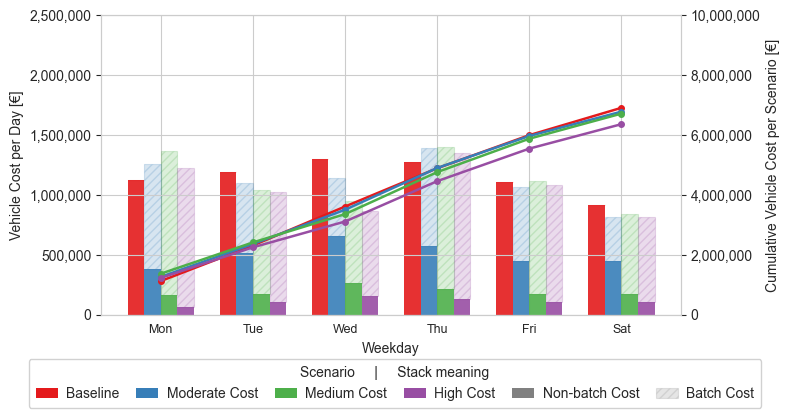

In [28]:

# ---------- 3) Plot ----------
# =============================================================================
# Stacked bars + cumulative line with synchronized y-axes
# =============================================================================

# ---------- 3) Pretty labels, order, palette ----------
scenario_display = {
    "basecase":      "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium":   "Medium Cost",
    "batchhigh":     "High Cost",
}
avg_cpp['scenario_label'] = avg_cpp['scenario'].map(scenario_display).fillna(avg_cpp['scenario'])

scenario_order = ["Baseline","Moderate Cost","Medium Cost","High Cost"]
present = [s for s in scenario_order if s in avg_cpp['scenario_label'].unique()]
if not present:
    present = sorted(avg_cpp['scenario_label'].unique())

palette = sns.color_palette("Set1", len(scenario_order))
color_map = dict(zip(scenario_order, palette))

scen_present = [s for s in scenario_order if s in work["scenario_label"].unique().tolist()]
if not scen_present:
    scen_present = sorted(work["scenario_label"].unique().tolist())


sns.set_style("whitegrid")

palette = sns.color_palette("Set1", len(scenario_order))
colors = dict(zip(scenario_order, palette))

fig, ax1 = plt.subplots(figsize=(8, 4))

x_pos = np.arange(len(weekday_order))
width = 0.18
hatch_pattern = "////"
edge_lw = 0.8

# Helper for thousands separator
fmt = FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", " "))
ax1.yaxis.set_major_formatter(fmt)

# ---------- Bars (stacked) ----------
for i, scen in enumerate(scen_present):
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order)
    nonbatch = sub["Non-batch cost"].to_numpy()
    batch = sub["Batch cost"].to_numpy()
    xpos = x_pos + (i - (len(scen_present) - 1) / 2.0) * width
    base_col = colors.get(scen, (0.5, 0.5, 0.5))

    ax1.bar(
        xpos, nonbatch, width=width,
        color=base_col, alpha=0.9,
        edgecolor="none"
    )
    ax1.bar(
        xpos, batch, width=width, bottom=nonbatch,
        facecolor=base_col, alpha=0.2,
        hatch=hatch_pattern, edgecolor=base_col, linewidth=edge_lw
    )

# ---------- Second axis (cumulative lines) ----------
ax2 = ax1.twinx()

max_y = 0
for scen in scen_present:
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order)
    total = sub["Batch cost"] + sub["Non-batch cost"]
    cumulative = total.cumsum()
    max_y = max(max_y, cumulative.max())

    ax2.plot(
        x_pos, cumulative,
        color=colors[scen],
        linewidth=1.8,
        marker="o", markersize=4,
        label=f"{scen} cumulative"
    )

from matplotlib.ticker import MaxNLocator, FuncFormatter

# --- 1) Fix axis limits you want ---
# --- 1) Fixed axis limits ---
ax2_min, ax2_max = 0.0, 10_00_0000.0     # right axis (cumulative)
ax1_min, ax1_max = 0.0,    2_500_000.0     # left axis (daily)
ax2.set_ylim(ax2_min, ax2_max)
ax1.set_ylim(ax1_min, ax1_max)

# --- 2) Generate “nice” ticks for the right axis ---
nbins = 6
ax2.yaxis.set_major_locator(MaxNLocator(nbins=nbins))
ax2_ticks = ax2.get_yticks()

# --- 3) Map those tick heights to the left axis (so grid lines match) ---
tick_fracs = (ax2_ticks - ax2_min) / (ax2_max - ax2_min)   # 0..1
ax1_ticks = ax1_min + tick_fracs * (ax1_max - ax1_min)
ax1.set_yticks(ax1_ticks)

# --- 4) Formatters ---
fmt = FuncFormatter(lambda v, _: f"{int(v):,}")
ax1.yaxis.set_major_formatter(fmt)
ax2.yaxis.set_major_formatter(fmt)

# --- 5) Grid ---
ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
ax1.set_axisbelow(True)

# 5) Formatter beibehalten
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ",")))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ",")))

# Optional: sicherstellen, dass das Grid exakt auf diesen (gemeinsamen) Tickpositionen liegt
ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# --- Achsenbeschriftungen & X-Ticks ---
ax1.set_xlabel("Weekday", fontsize=10)
ax1.set_ylabel("Vehicle Cost per Day [€]", fontsize=10)
ax2.set_ylabel("Cumulative Vehicle Cost per Scenario [€]", fontsize=10)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(weekday_labels, fontsize=9)

# =========================
# Gemeinsame Legende unten
# =========================
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 4 Szenario-Farbflächen
scenario_handles = [Patch(facecolor=colors[s], edgecolor="none", label=s) for s in scen_present]

# 2 Stack-Bedeutungen (neutral grau dargestellt)
stack_handles = [
    Patch(facecolor="gray", edgecolor="none", label="Non-batch Cost"),
    Patch(facecolor="gray", alpha=0.20, hatch="////", edgecolor="gray", linewidth=0.8, label="Batch Cost"),
]

# zu einer Legende kombinieren
handles = scenario_handles + stack_handles
labels  = [h.get_label() for h in handles]

leg = fig.legend(
    handles, labels,
    loc="lower center", bbox_to_anchor=(0.5, -0.05),
    ncol=len(handles), frameon=True, fancybox=True, framealpha=0.9,
    title="Scenario     |     Stack meaning",  # kurzer Titel
    handlelength=1.6, handletextpad=0.6, columnspacing=1.2, borderpad=0.5
)

# Damit unten Platz ist
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig("cost_all_scenarios.pdf", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_42248\3112740396.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  work.groupby(['scenario','weekday','run_name'], dropna=False)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_42248\3112740396.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['scenario','weekday'], as_index=False)['cost_per_parcel_day']
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_42248\3112740396.py:113: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or

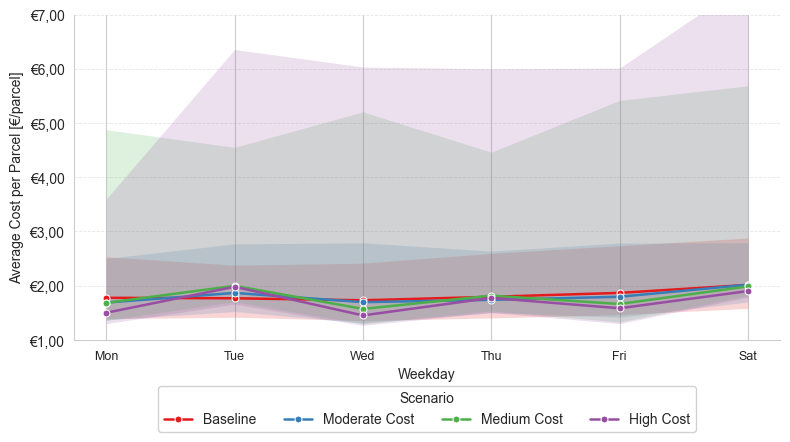

In [51]:
# =============================================================================
# Average Cost per Parcel by Weekday (Mon–Sat), paper-ready plot
# =============================================================================
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ---------- 0) Preconditions ----------
if 'df_all' not in globals() or df_all is None or len(df_all) == 0:
    raise RuntimeError("df_all is empty or not loaded.")

work = df_all.copy()

# Required numeric inputs
for col in ['vehicle_cost', 'deliveries']:
    if col not in work.columns:
        raise RuntimeError(f"Required column '{col}' missing in df_all.")
work['vehicle_cost'] = pd.to_numeric(work['vehicle_cost'], errors='coerce').fillna(0.0)
work['deliveries']   = pd.to_numeric(work['deliveries'],   errors='coerce').fillna(0.0)

# Scenario from run_name prefix
if 'run_name' not in work.columns:
    raise RuntimeError("'run_name' missing in df_all; ensure loader added it.")
work['scenario'] = work['run_name'].astype(str).str.split('_').str[0]

# ---------- 1) Weekday extraction ----------
from datetime import datetime as _dt

def _extract_day(run):
    m = re.search(r'_(\d{8})_', str(run))
    return m.group(1) if m else None

weekday_order  = ['Mon','Tue','Wed','Thu','Fri','Sat']
weekday_labels = weekday_order

def _weekday_label(day_token):
    try:
        d = _dt.strptime(day_token, '%d%m%Y').date()
        return ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][d.weekday()]
    except Exception:
        return None

work['day_token'] = work['run_name'].map(_extract_day)
work['weekday']   = work['day_token'].map(_weekday_label)
work = work[work['weekday'].isin(weekday_order)].copy()
work['weekday'] = pd.Categorical(work['weekday'], categories=weekday_order, ordered=True)

# ---------- 2) Aggregate: per-run day totals, then average over runs ----------
per_run = (
    work.groupby(['scenario','weekday','run_name'], dropna=False)
        .agg(total_cost=('vehicle_cost','sum'),
             total_deliveries=('deliveries','sum'))
        .reset_index()
)
per_run['cost_per_parcel_day'] = np.where(
    per_run['total_deliveries'] > 0,
    per_run['total_cost'] / per_run['total_deliveries'],
    np.nan
)

avg_cpp = (per_run
           .groupby(['scenario','weekday'], as_index=False)['cost_per_parcel_day']
           .mean())

# ---------- 3) Pretty labels, order, palette ----------
scenario_display = {
    "basecase":      "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium":   "Medium Cost",
    "batchhigh":     "High Cost",
}
avg_cpp['scenario_label'] = avg_cpp['scenario'].map(scenario_display).fillna(avg_cpp['scenario'])

scenario_order = ["Baseline","Moderate Cost","Medium Cost","High Cost"]
present = [s for s in scenario_order if s in avg_cpp['scenario_label'].unique()]
if not present:
    present = sorted(avg_cpp['scenario_label'].unique())

palette = sns.color_palette("Set1", len(scenario_order))
color_map = dict(zip(scenario_order, palette))

# ---------- 4) Plot (paper-ready) ----------
sns.set_style("whitegrid")
plt.figure(figsize=(8, 4.5))

def euro_fmt(v, _):
    if pd.isna(v):
        return ""
    return f"€{v:,.2f}".replace(",", " ").replace(".", ",")

ax = sns.lineplot(
    data=avg_cpp.sort_values(['scenario_label','weekday']),
    x='weekday', y='cost_per_parcel_day',
    hue='scenario_label', hue_order=present,
    palette=color_map,
    marker='o', markersize=5, linewidth=1.8,  zorder=9999
)

# --- 2) Szenario-Mittel (bleibt wie gehabt, nur zorder etwas höher) ---
# sns.lineplot(
#     data=avg_cpp.sort_values(['scenario_label','weekday']),
#     x='weekday', y='cost_per_parcel_day',
#     hue='scenario_label', hue_order=draw_order,
#     palette=color_map, marker='o', markersize=5, linewidth=2.0,
#     ax=ax, zorder=len(draw_order)+2
# )

per_run_carrier = (
    work.groupby(['scenario','provider','weekday','run_name'], dropna=False)
        .agg(total_cost=('vehicle_cost','sum'),
             total_deliveries=('deliveries','sum'))
        .reset_index()
)
per_run_carrier['cost_per_parcel_day'] = np.where(
    per_run_carrier['total_deliveries'] > 0,
    per_run_carrier['total_cost'] / per_run_carrier['total_deliveries'],
    np.nan
)

# Average per carrier (still per scenario x weekday)
avg_cpp_carrier = (
    per_run_carrier.groupby(['scenario','provider','weekday'], as_index=False)['cost_per_parcel_day']
                   .mean()
)

for df_ in [avg_cpp, avg_cpp_carrier]:
    df_['scenario_label'] = df_['scenario'].map(scenario_display).fillna(df_['scenario'])


# --- 1) Faint scenario bands (e.g., 10–90% over carriers), drawn in order ---
draw_order = ["Baseline", "Moderate Cost", "Medium Cost", "High Cost"][:]
weekday_idx = dict(zip(weekday_order, range(len(weekday_order))))  # {"Mon":0,...}

for z, scen in enumerate(draw_order, start=1):
    if scen not in avg_cpp_carrier["scenario_label"].unique():
        continue
    col = color_map[scen]

    # Verteilung über Carrier je Wochentag
    sub = avg_cpp_carrier.loc[avg_cpp_carrier["scenario_label"] == scen,
                              ["weekday", "cost_per_parcel_day"]].copy()

    band = (sub.groupby("weekday", as_index=False)["cost_per_parcel_day"]
              .agg(low=lambda s: np.nanpercentile(s, 0),
                   high=lambda s: np.nanpercentile(s, 100))
              .sort_values("weekday"))

    x = band["weekday"].map(weekday_idx).to_numpy()
    low = band["low"].to_numpy()
    high = band["high"].to_numpy()

    # Transparentes Band
    ax.fill_between(
        x, low, high, color=col, alpha=0.18, linewidth=0, zorder=z  # zorder steuert Malreihenfolge
    )
        
        
# Axes & labels
ax.set_xlabel("Weekday", fontsize=10)
ax.set_ylabel("Average Cost per Parcel [€/parcel]", fontsize=10)
ax.set_xticks(range(len(weekday_labels)))
ax.set_xticklabels(weekday_labels, fontsize=9)
ax.yaxis.set_major_formatter(FuncFormatter(euro_fmt))

# Grid & spines
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

# Legend below in one row
leg = ax.legend(
    title="Scenario",
    loc="upper center", bbox_to_anchor=(0.5, -0.12),
    ncol=len(present), frameon=True, fancybox=True, framealpha=0.9
)
plt.tight_layout()

ax.set_ylim(1,7)


plt.savefig("avg_cost_per_parcel_by_weekday.pdf", dpi=300, bbox_inches="tight")
plt.show()




In [67]:
import re
from datetime import datetime

# --- 4) Derive ISO week from run_name and aggregate weekly totals -------------
def _date_from_runname(run_name):
    m = re.search(r"_(\d{8})_", str(run_name))
    if not m:
        return None
    try:
        return datetime.strptime(m.group(1), "%d%m%Y")
    except Exception:
        return None

work["run_date"] = work["run_name"].apply(_date_from_runname)
if work["run_date"].isna().all():
    raise RuntimeError("No parsable dates found in run_name pattern _DDMMYYYY_. Cannot build weekly summary.")

# ISO week label like 2025-W12
iso_triplet = work["run_date"].apply(lambda d: d.isocalendar() if pd.notna(d) else None)
work["iso_year"] = iso_triplet.apply(lambda t: t[0] if t is not None else np.nan)
work["iso_week"] = iso_triplet.apply(lambda t: t[1] if t is not None else np.nan)
work["week_label"] = work.apply(
    lambda r: f"{int(r['iso_year'])}-W{int(r['iso_week']):02d}" if pd.notna(r["iso_year"]) and pd.notna(r["iso_week"]) else None,
    axis=1
)

# Weekly totals per scenario
weekly_summary = (
    work.dropna(subset=["week_label"])
        .groupby(["scenario_label","week_label"], dropna=False)
        .agg(total_cost=("vehicle_cost","sum"),
             total_deliveries=("deliveries","sum"))
        .reset_index()
)

weekly_summary["avg_cost_per_parcel"] = weekly_summary["total_cost"] / weekly_summary["total_deliveries"]

# Optional: percent vs Baseline within the same week (only if baseline exists for that week)
base_week = (
    weekly_summary[weekly_summary["scenario_label"] == "Baseline"]
        .set_index("week_label")["avg_cost_per_parcel"]
)

weekly_summary["pct_vs_baseline"] = weekly_summary.apply(
    lambda r: (r["avg_cost_per_parcel"] / base_week.get(r["week_label"], np.nan) - 1.0) * 100.0,
    axis=1
)

# Sort for clean printing
weekly_summary = weekly_summary.sort_values(by=["week_label","scenario_label"]).reset_index(drop=True)

# --- 5) Print weekly report ---------------------------------------------------
print("\n=== Weekly totals per scenario ===")
for scen in weekly_summary["scenario_label"].unique():
    print(f"\nScenario: {scen}")
    sub = weekly_summary[weekly_summary["scenario_label"] == scen].sort_values("week_label")
    for _, row in sub.iterrows():
        tc = row["total_cost"]
        td = row["total_deliveries"]
        ac = row["avg_cost_per_parcel"]
        pct = row["pct_vs_baseline"]
        pct_str = f" ({pct:+.1f} % vs Baseline)" if np.isfinite(pct) else ""
        print(f"  {row['week_label']:>9s}: total_cost={tc:,.2f}, deliveries={int(td):d}, avg_cost_per_parcel={ac:.4f}{pct_str}")



=== Weekly totals per scenario ===

Scenario: Baseline
   2025-W20: total_cost=4,601,233.76, deliveries=2538882, avg_cost_per_parcel=1.8123 (+0.0 % vs Baseline)

Scenario: High Cost
   2025-W20: total_cost=4,241,550.34, deliveries=2534384, avg_cost_per_parcel=1.6736 (-7.7 % vs Baseline)

Scenario: Medium Cost
   2025-W20: total_cost=4,476,625.81, deliveries=2534183, avg_cost_per_parcel=1.7665 (-2.5 % vs Baseline)

Scenario: Moderate Cost
   2025-W20: total_cost=4,517,018.46, deliveries=2537871, avg_cost_per_parcel=1.7798 (-1.8 % vs Baseline)


In [61]:
work

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,initial_delivery_distance,vehicle_load_factor,is_van,is_ev,emissions,main_area_type_name,Cost per Parcel [€/parcel],carrier_category,scenario,scenario_label
0,freight_fedex_31832_veh_cep_size_m_7_1,24139.0,72066.0,13.313056,18233.0,8.248333,1970-01-01 06:42:19,1970-01-01 20:01:06,1970-01-01 13:18:47,1970-01-01 05:03:53,...,NaN,NaN,NaN,NaN,NaN,NaN,2.656254,B2B,basecase,Baseline
1,freight_gls_31535_veh_cep_size_l_7_1,24722.0,64152.0,10.952778,10584.0,8.012778,1970-01-01 06:52:02,1970-01-01 17:49:12,1970-01-01 10:57:10,1970-01-01 02:56:24,...,NaN,NaN,NaN,NaN,NaN,NaN,4.139754,Mixed,basecase,Baseline
2,freight_ups_31311_veh_cep_size_m_7_1,25075.0,69743.0,12.407778,14136.0,8.481111,1970-01-01 06:57:55,1970-01-01 19:22:23,1970-01-01 12:24:28,1970-01-01 03:55:36,...,NaN,NaN,NaN,NaN,NaN,NaN,3.246762,B2B,basecase,Baseline
3,freight_ups_31832_veh_cep_size_m_7_1,25101.0,72941.0,13.288889,17985.0,8.293056,1970-01-01 06:58:21,1970-01-01 20:15:41,1970-01-01 13:17:20,1970-01-01 04:59:45,...,NaN,NaN,NaN,NaN,NaN,NaN,2.695286,B2B,basecase,Baseline
4,freight_gls_31535_veh_cep_size_m_7_5,25208.0,63241.0,10.564722,11392.0,7.400278,1970-01-01 07:00:08,1970-01-01 17:34:01,1970-01-01 10:33:53,1970-01-01 03:09:52,...,NaN,NaN,NaN,NaN,NaN,NaN,3.574697,Mixed,basecase,Baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79269,freight_amazon_30900_1_veh_cep_size_m_16_5,58148.0,64111.0,NaN,1873.0,NaN,1970-01-01 16:09:08,1970-01-01 17:48:31,1970-01-01 01:39:23,1970-01-01 00:31:13,...,18.844908,0.090909,True,1.0,"{'drive': 0.0, 'idle': 0.0, 'cold': 0.0, 'tota...",Rural with Industrial Influence,12.620688,B2C,batchmoderate,Moderate Cost
79270,freight_amazon_31319_1_veh_cep_size_m_17_4,60689.0,74985.0,NaN,3630.0,NaN,1970-01-01 16:51:29,1970-01-01 20:49:45,1970-01-01 03:58:16,1970-01-01 01:00:30,...,34.231393,0.181818,True,1.0,"{'drive': 0.0, 'idle': 0.0, 'cold': 0.0, 'tota...",Urbanized Periphery,6.881250,B2C,batchmoderate,Moderate Cost
79271,freight_amazon_30826_veh_cep_size_m_17_5,62458.0,71712.0,NaN,4035.0,NaN,1970-01-01 17:20:58,1970-01-01 19:55:12,1970-01-01 02:34:14,1970-01-01 01:07:15,...,4.331356,0.193939,True,1.0,"{'drive': 0.0, 'idle': 0.0, 'cold': 0.0, 'tota...",Rural with Industrial Influence,5.886592,B2C,batchmoderate,Moderate Cost
79272,freight_amazon_31275_0_veh_cep_size_m_17_6,62620.0,67565.0,NaN,1848.0,NaN,1970-01-01 17:23:40,1970-01-01 18:46:05,1970-01-01 01:22:25,1970-01-01 00:30:48,...,32.424032,0.090909,True,1.0,"{'drive': 0.0, 'idle': 0.0, 'cold': 0.0, 'tota...",Urbanized Periphery,13.183782,B2C,batchmoderate,Moderate Cost


In [66]:
work.groupby("scenario")["overtime_cost"].sum()

scenario
basecase         327539.985283
batchhigh        173448.938750
batchmedium      206677.701961
batchmoderate    321065.628044
Name: overtime_cost, dtype: float64

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_42248\751439224.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cost_daily = (work.groupby(['scenario','weekday'], as_index=False)['vehicle_cost']


[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\cumulative_total_cost_by_weekday.csv


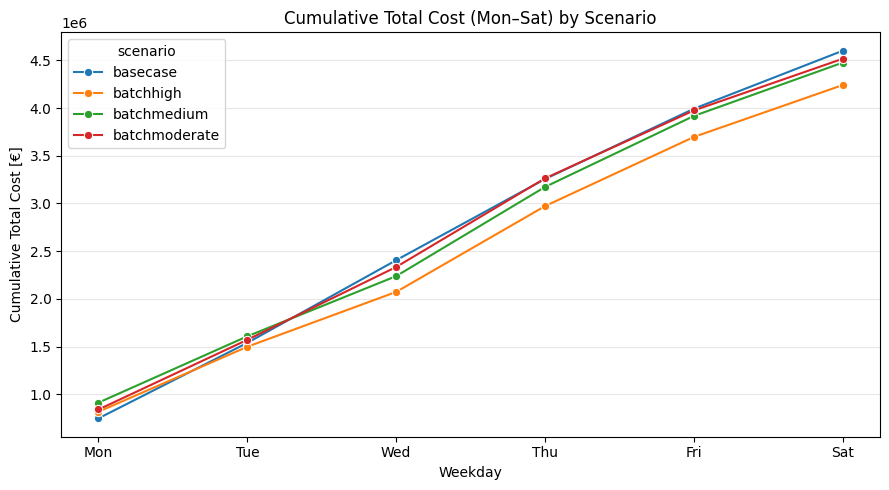

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_cumulative_total_cost_by_weekday.png


In [5]:
# Cumulative Total Cost from Monday to Saturday by Scenario (combined line chart)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preconditions
if 'df_all' not in globals() or df_all is None or len(df_all) == 0:
    raise RuntimeError("df_all is empty or not loaded. Run the loader cell above.")

work = df_all.copy()

# Ensure needed numeric column
if 'vehicle_cost' not in work.columns:
    raise RuntimeError("Required column 'vehicle_cost' missing in df_all.")
work['vehicle_cost'] = pd.to_numeric(work['vehicle_cost'], errors='coerce').fillna(0.0)

# Scenario from run_name
if 'run_name' not in work.columns:
    raise RuntimeError("'run_name' missing in df_all; ensure loader added it.")
work['scenario'] = work['run_name'].str.split('_').str[0]

# Weekday parsing
import datetime as _dt

def _extract_day(run):
    parts = str(run).split('_')
    return parts[1] if len(parts) >= 3 and parts[1].isdigit() and len(parts[1]) == 8 else None

work['day_token'] = work['run_name'].map(_extract_day)

weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

def _weekday_label(day_token):
    try:
        d = _dt.datetime.strptime(day_token, '%d%m%Y').date()
        return ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][d.weekday()]
    except Exception:
        return None

work['weekday'] = work['day_token'].map(_weekday_label)
work = work[work['weekday'].isin(weekday_order)].copy()
work['weekday'] = pd.Categorical(work['weekday'], categories=weekday_order, ordered=True)

# Aggregate total cost per scenario x weekday across all runs
cost_daily = (work.groupby(['scenario','weekday'], as_index=False)['vehicle_cost']
                 .sum().rename(columns={'vehicle_cost':'total_cost'}) )

# Compute cumulative total cost Mon–Sat per scenario
cost_daily = cost_daily.sort_values(['scenario','weekday'])
cost_daily['cum_total_cost'] = cost_daily.groupby('scenario', group_keys=False)['total_cost'].cumsum()

# Persist CSV
out_csv_cum = os.path.join(OUTPUT_BASE, 'cumulative_total_cost_by_weekday.csv')
cost_daily.to_csv(out_csv_cum, index=False)
print(f"[OK] Saved {out_csv_cum}")

# Plot combined line chart
plt.figure(figsize=(9,5))
sns.lineplot(data=cost_daily, x='weekday', y='cum_total_cost', hue='scenario', marker='o')
plt.title('Cumulative Total Cost (Mon–Sat) by Scenario')
plt.ylabel('Cumulative Total Cost [€]')
plt.xlabel('Weekday')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
fig_cum_cost = os.path.join(OUTPUT_BASE, 'plot_cumulative_total_cost_by_weekday.png')
plt.savefig(fig_cum_cost, dpi=150)
plt.show()
print(f"[OK] Saved {fig_cum_cost}")

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_42248\619333581.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cost_daily = (work.groupby(['provider','scenario','weekday'], as_index=False)['vehicle_cost']


[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\cumulative_total_cost_by_weekday_and_provider.csv


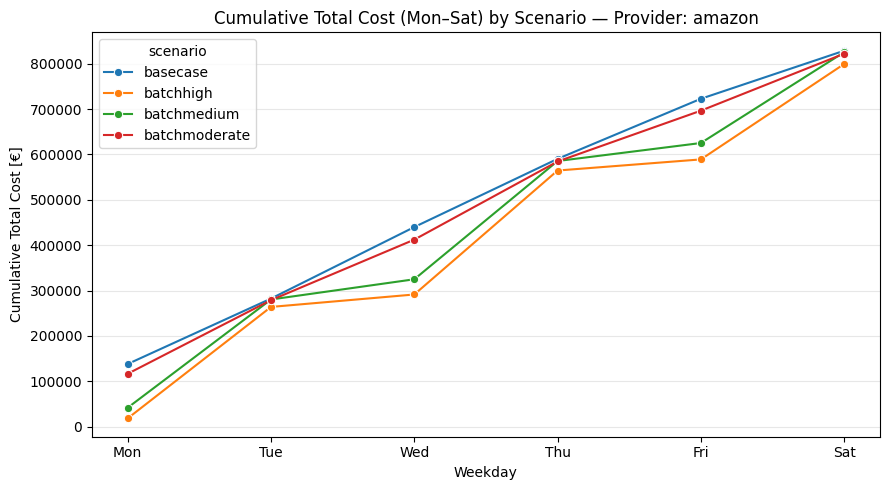

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_cumulative_total_cost_by_weekday_provider_amazon.png


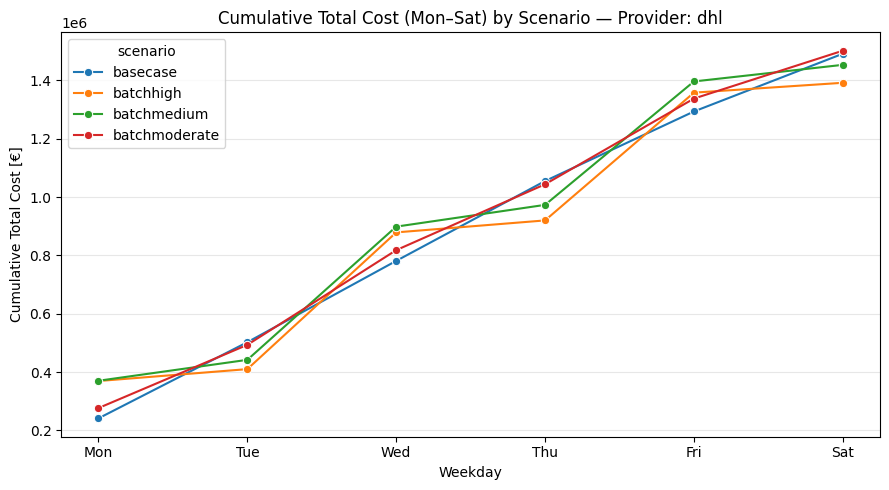

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_cumulative_total_cost_by_weekday_provider_dhl.png


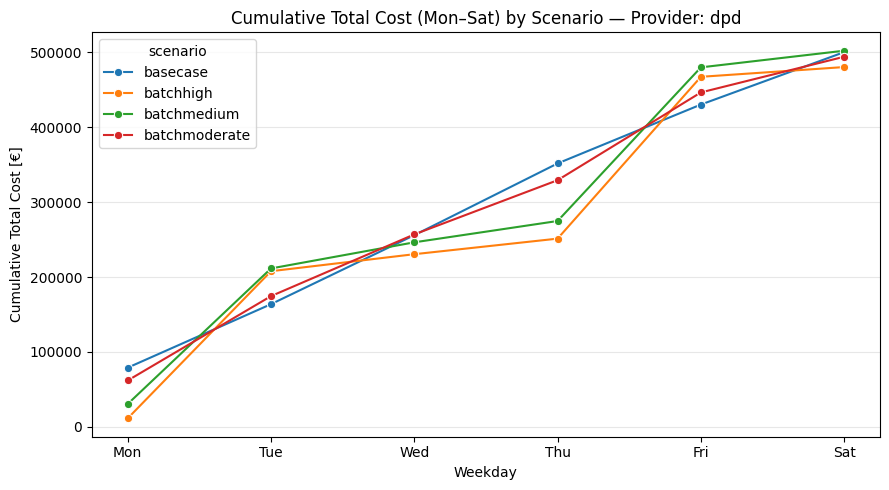

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_cumulative_total_cost_by_weekday_provider_dpd.png


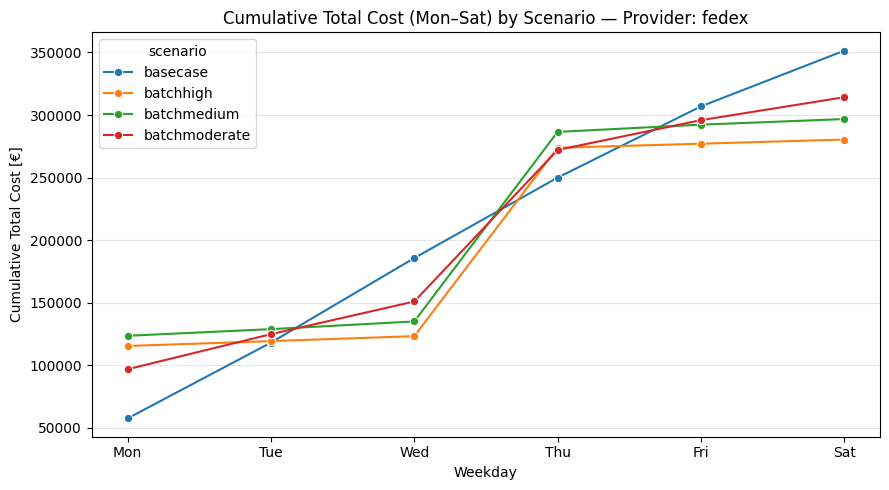

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_cumulative_total_cost_by_weekday_provider_fedex.png


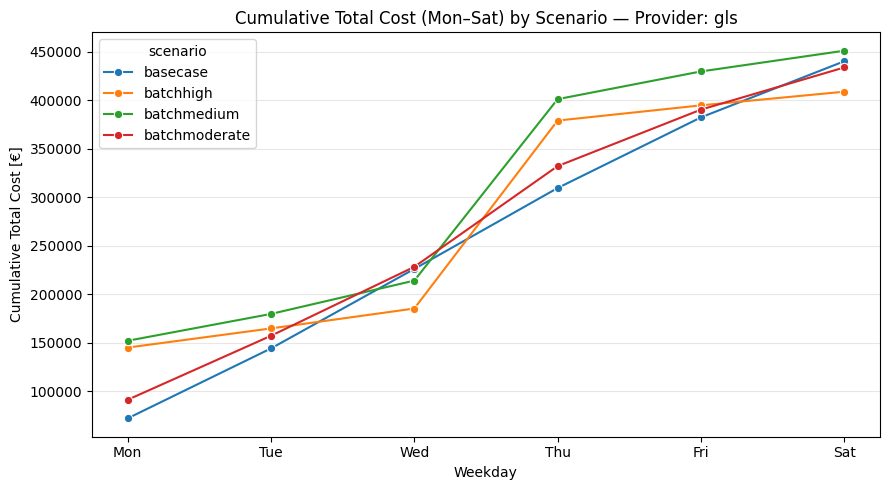

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_cumulative_total_cost_by_weekday_provider_gls.png


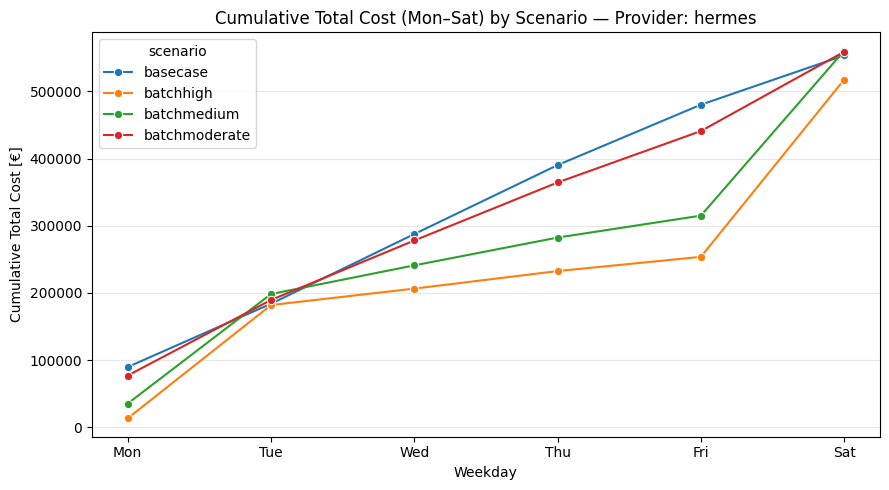

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_cumulative_total_cost_by_weekday_provider_hermes.png


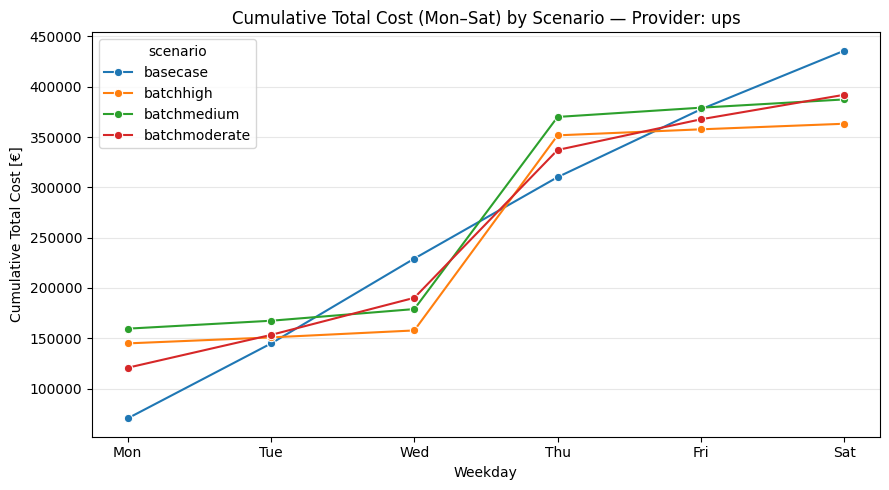

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_cumulative_total_cost_by_weekday_provider_ups.png


In [6]:
# Cumulative Total Cost Mon–Sat by Scenario, per Provider (one plot per provider)
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preconditions
if 'df_all' not in globals() or df_all is None or len(df_all) == 0:
    raise RuntimeError("df_all is empty or not loaded. Run the loader cell above.")

work = df_all.copy()

# Ensure needed numeric column
if 'vehicle_cost' not in work.columns:
    raise RuntimeError("Required column 'vehicle_cost' missing in df_all.")
work['vehicle_cost'] = pd.to_numeric(work['vehicle_cost'], errors='coerce').fillna(0.0)

# Scenario from run_name
if 'run_name' not in work.columns:
    raise RuntimeError("'run_name' missing in df_all; ensure loader added it.")
work['scenario'] = work['run_name'].str.split('_').str[0]

# Provider detection: prefer explicit provider columns, else derive from carrier id using getProviderFromID
provider_col = next((c for c in ['provider','logisticProvider','carrier_provider'] if c in work.columns), None)
if provider_col is not None:
    work['provider'] = work[provider_col].astype(str)
else:
    carrier_candidates = ['carrierID','carrierId','carrier_id','carrier','carrier_id_str']
    carrier_col = next((c for c in carrier_candidates if c in work.columns), None)
    if carrier_col is None:
        raise RuntimeError("No provider/carrier column found; expected one of provider/logisticProvider/carrier_provider or carrierID/carrier_id/carrier.")
    # getProviderFromID is defined earlier in this notebook
    work['provider'] = work[carrier_col].map(getProviderFromID)

# Weekday parsing
import datetime as _dt

def _extract_day(run):
    parts = str(run).split('_')
    return parts[1] if len(parts) >= 3 and parts[1].isdigit() and len(parts[1]) == 8 else None

work['day_token'] = work['run_name'].map(_extract_day)

weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

def _weekday_label(day_token):
    try:
        d = _dt.datetime.strptime(day_token, '%d%m%Y').date()
        return ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][d.weekday()]
    except Exception:
        return None

work['weekday'] = work['day_token'].map(_weekday_label)
work = work[work['weekday'].isin(weekday_order)].copy()
work['weekday'] = pd.Categorical(work['weekday'], categories=weekday_order, ordered=True)

# Aggregate total cost per provider x scenario x weekday across all runs
cost_daily = (work.groupby(['provider','scenario','weekday'], as_index=False)['vehicle_cost']
                 .sum().rename(columns={'vehicle_cost':'total_cost'}))

# Compute cumulative total cost Mon–Sat per provider x scenario
cost_daily = cost_daily.sort_values(['provider','scenario','weekday'])
cost_daily['cum_total_cost'] = (cost_daily
                                .groupby(['provider','scenario'], group_keys=False)['total_cost']
                                .cumsum())

# Persist combined CSV
out_csv = os.path.join(OUTPUT_BASE, 'cumulative_total_cost_by_weekday_and_provider.csv')
cost_daily.to_csv(out_csv, index=False)
print(f"[OK] Saved {out_csv}")

# One plot per provider: scenarios as lines
providers = sorted(cost_daily['provider'].dropna().astype(str).unique())
for prov in providers:
    sub = cost_daily[cost_daily['provider'] == prov]
    if sub.empty:
        continue
    plt.figure(figsize=(9,5))
    sns.lineplot(data=sub, x='weekday', y='cum_total_cost', hue='scenario', marker='o')
    plt.title(f'Cumulative Total Cost (Mon–Sat) by Scenario — Provider: {prov}')
    plt.ylabel('Cumulative Total Cost [€]')
    plt.xlabel('Weekday')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    safe = re.sub(r'[^a-zA-Z0-9_-]+', '_', str(prov))
    fig_path = os.path.join(OUTPUT_BASE, f'plot_cumulative_total_cost_by_weekday_provider_{safe}.png')
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print(f"[OK] Saved {fig_path}")

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_42248\2393789765.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cost_daily = (work.groupby(['provider','scenario','weekday'], as_index=False)['vehicle_cost']


[INFO] Baseline scenario detected: 'basecase'
[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\delta_total_cost_vs_baseline_by_provider.csv


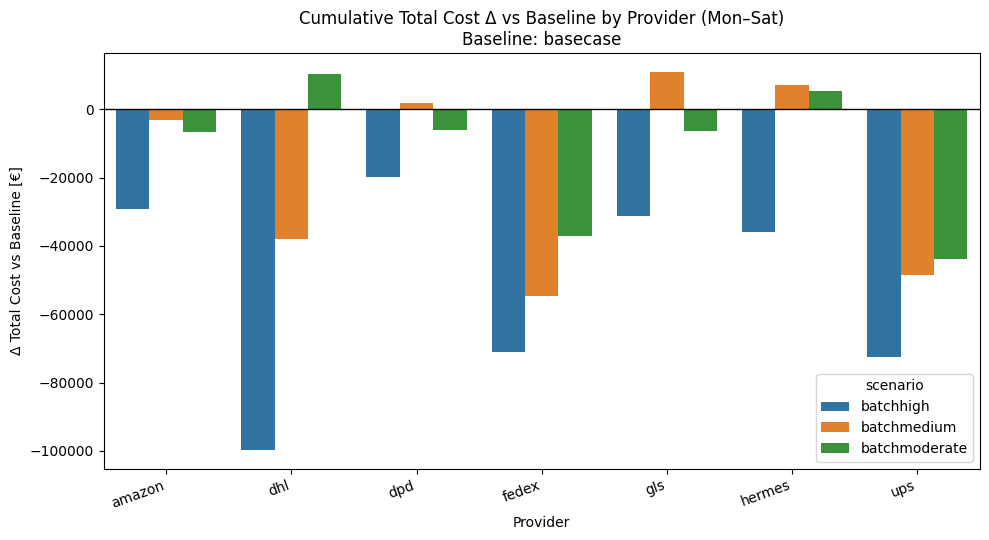

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_delta_total_cost_vs_baseline_by_provider.png
[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\total_delta_total_cost_vs_baseline.csv


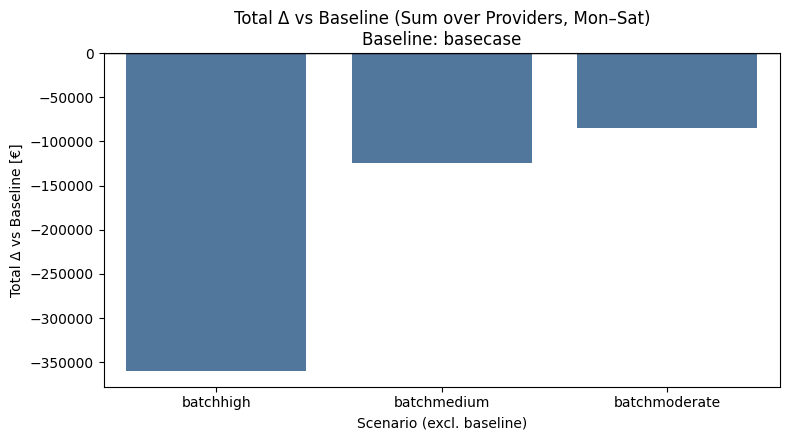

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_total_delta_total_cost_vs_baseline.png


In [7]:
# Provider delta vs baseline (cumulative Mon–Sat total cost)
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preconditions
if 'df_all' not in globals() or df_all is None or len(df_all) == 0:
    raise RuntimeError("df_all is empty or not loaded. Run the loader cell above.")

work = df_all.copy()

# Ensure needed numeric column
if 'vehicle_cost' not in work.columns:
    raise RuntimeError("Required column 'vehicle_cost' missing in df_all.")
work['vehicle_cost'] = pd.to_numeric(work['vehicle_cost'], errors='coerce').fillna(0.0)

# Scenario from run_name
if 'run_name' not in work.columns:
    raise RuntimeError("'run_name' missing in df_all; ensure loader added it.")
work['scenario'] = work['run_name'].str.split('_').str[0]

# Provider detection: prefer explicit provider columns, else derive from carrier id using getProviderFromID
provider_col = next((c for c in ['provider','logisticProvider','carrier_provider'] if c in work.columns), None)
if provider_col is not None:
    work['provider'] = work[provider_col].astype(str)
else:
    carrier_candidates = ['carrierID','carrierId','carrier_id','carrier','carrier_id_str']
    carrier_col = next((c for c in carrier_candidates if c in work.columns), None)
    if carrier_col is None:
        raise RuntimeError("No provider/carrier column found; expected one of provider/logisticProvider/carrier_provider or carrierID/carrier_id/carrier.")
    # getProviderFromID is defined earlier in this notebook
    work['provider'] = work[carrier_col].map(getProviderFromID)

# Weekday parsing from <scenario>_<DDMMYYYY>_
import datetime as _dt

def _extract_day(run):
    parts = str(run).split('_')
    return parts[1] if len(parts) >= 3 and parts[1].isdigit() and len(parts[1]) == 8 else None

work['day_token'] = work['run_name'].map(_extract_day)

weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

def _weekday_label(day_token):
    try:
        d = _dt.datetime.strptime(day_token, '%d%m%Y').date()
        return ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][d.weekday()]
    except Exception:
        return None

work['weekday'] = work['day_token'].map(_weekday_label)
work = work[work['weekday'].isin(weekday_order)].copy()
work['weekday'] = pd.Categorical(work['weekday'], categories=weekday_order, ordered=True)

# Aggregate total cost per provider x scenario x weekday across all runs and compute cumulative (Mon–Sat)
cost_daily = (work.groupby(['provider','scenario','weekday'], as_index=False)['vehicle_cost']
                 .sum().rename(columns={'vehicle_cost':'total_cost'}))

cost_daily = cost_daily.sort_values(['provider','scenario','weekday'])
cost_daily['cum_total_cost'] = (cost_daily
                                .groupby(['provider','scenario'], group_keys=False)['total_cost']
                                .cumsum())

# Take the last available weekday per provider x scenario (usually Sat)
last_rows = (cost_daily
             .sort_values(['provider','scenario','weekday'])
             .groupby(['provider','scenario'], as_index=False)
             .tail(1))

# Detect baseline scenario
scenarios = sorted(last_rows['scenario'].astype(str).unique())

def detect_baseline(cands):
    keys = ['baseline','base','bau','ref','reference','statusquo','status_quo','status-quo','basis','default']
    for k in keys:
        for s in cands:
            if k in s.lower():
                return s
    return None

BASELINE_SCENARIO = detect_baseline(scenarios)
if BASELINE_SCENARIO is None:
    # Fallback: pick the first scenario alphabetically and warn
    BASELINE_SCENARIO = scenarios[0]
    print(f"[WARN] No explicit baseline scenario found. Using '{BASELINE_SCENARIO}' as baseline.")
else:
    print(f"[INFO] Baseline scenario detected: '{BASELINE_SCENARIO}'")

# Compute delta vs baseline per provider and scenario
base_map = (last_rows[last_rows['scenario'] == BASELINE_SCENARIO]
            .set_index('provider')['cum_total_cost'])

final = last_rows.copy()
final['baseline_total'] = final['provider'].map(base_map)
final['delta_vs_baseline'] = final['cum_total_cost'] - final['baseline_total']

# Drop baseline scenario from plotting (it will be zero)
final_nonbase = final[final['scenario'] != BASELINE_SCENARIO].copy()

# Persist CSV for per-provider deltas
out_csv_provider = os.path.join(OUTPUT_BASE, 'delta_total_cost_vs_baseline_by_provider.csv')
final_nonbase[['provider','scenario','cum_total_cost','baseline_total','delta_vs_baseline']].to_csv(out_csv_provider, index=False)
print(f"[OK] Saved {out_csv_provider}")

# Plot grouped bars: x=provider, hue=scenario, y=delta
plt.figure(figsize=(10,5.5))
sns.barplot(data=final_nonbase.sort_values(['provider','scenario']), x='provider', y='delta_vs_baseline', hue='scenario')
plt.axhline(0, color='black', linewidth=1)
plt.title(f"Cumulative Total Cost Δ vs Baseline by Provider (Mon–Sat)\nBaseline: {BASELINE_SCENARIO}")
plt.ylabel('Δ Total Cost vs Baseline [€]')
plt.xlabel('Provider')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
fig_provider = os.path.join(OUTPUT_BASE, 'plot_delta_total_cost_vs_baseline_by_provider.png')
plt.savefig(fig_provider, dpi=150)
plt.show()
print(f"[OK] Saved {fig_provider}")

# Aggregate overall delta across providers per scenario (excluding baseline)
overall = (final_nonbase.groupby('scenario', as_index=False)['delta_vs_baseline']
                   .sum().rename(columns={'delta_vs_baseline':'sum_delta_vs_baseline'}))

out_csv_overall = os.path.join(OUTPUT_BASE, 'total_delta_total_cost_vs_baseline.csv')
overall.to_csv(out_csv_overall, index=False)
print(f"[OK] Saved {out_csv_overall}")

plt.figure(figsize=(8,4.5))
sns.barplot(data=overall.sort_values('scenario'), x='scenario', y='sum_delta_vs_baseline', color='#4477aa')
plt.axhline(0, color='black', linewidth=1)
plt.title(f"Total Δ vs Baseline (Sum over Providers, Mon–Sat)\nBaseline: {BASELINE_SCENARIO}")
plt.ylabel('Total Δ vs Baseline [€]')
plt.xlabel('Scenario (excl. baseline)')
plt.tight_layout()
fig_overall = os.path.join(OUTPUT_BASE, 'plot_total_delta_total_cost_vs_baseline.png')
plt.savefig(fig_overall, dpi=150)
plt.show()
print(f"[OK] Saved {fig_overall}")

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_42248\3634302793.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cost_daily = (work.groupby(['provider','scenario','weekday'], as_index=False)['vehicle_cost']


[INFO] Baseline scenario detected: 'basecase'
[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\delta_total_cost_vs_baseline_by_provider.csv


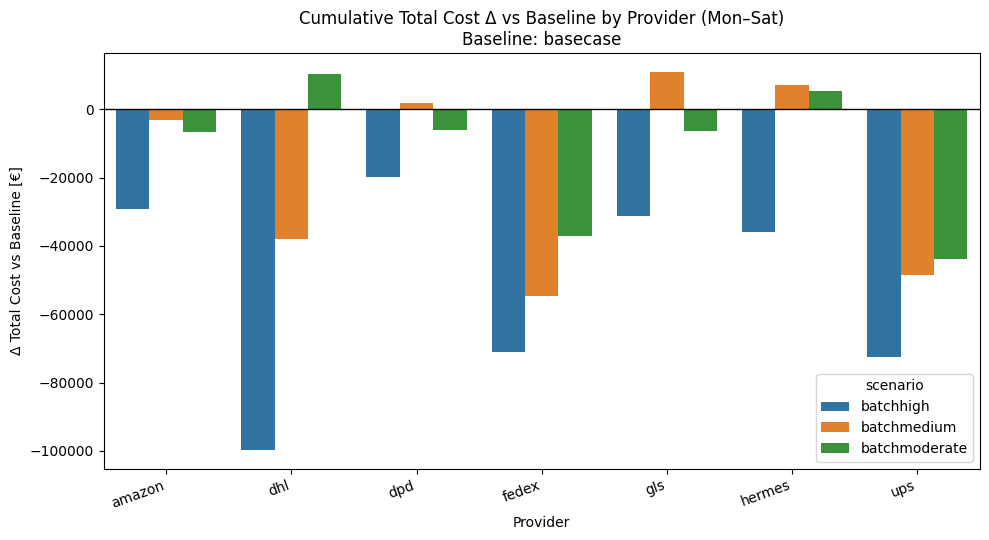

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_delta_total_cost_vs_baseline_by_provider.png


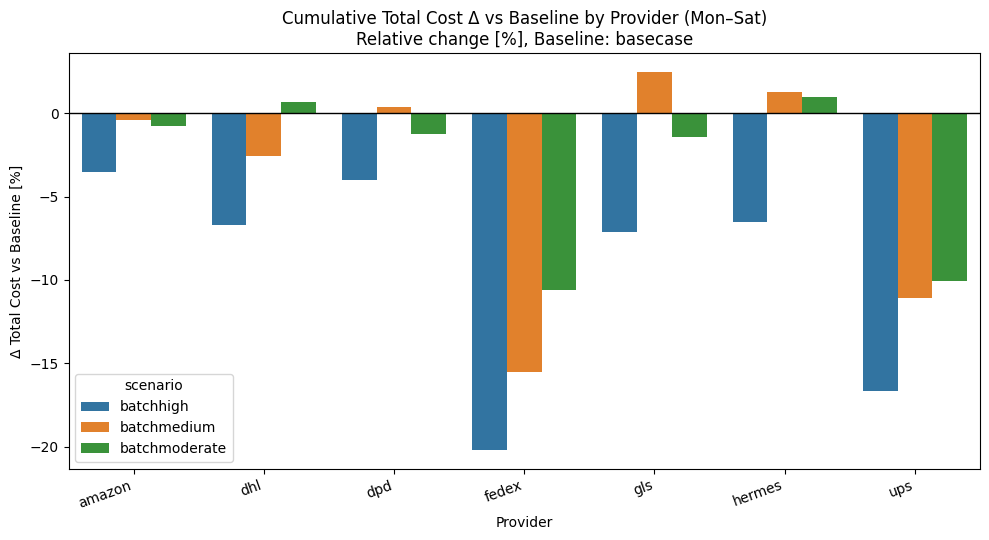

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_rel_delta_total_cost_vs_baseline_by_provider.png
[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\total_delta_total_cost_vs_baseline.csv


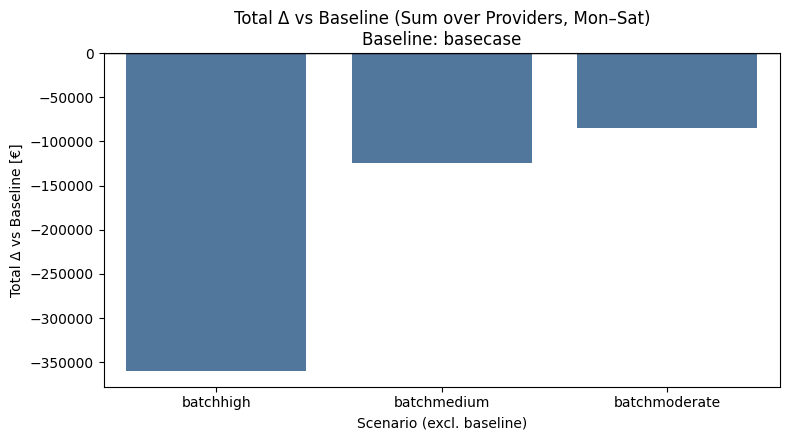

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_total_delta_total_cost_vs_baseline.png


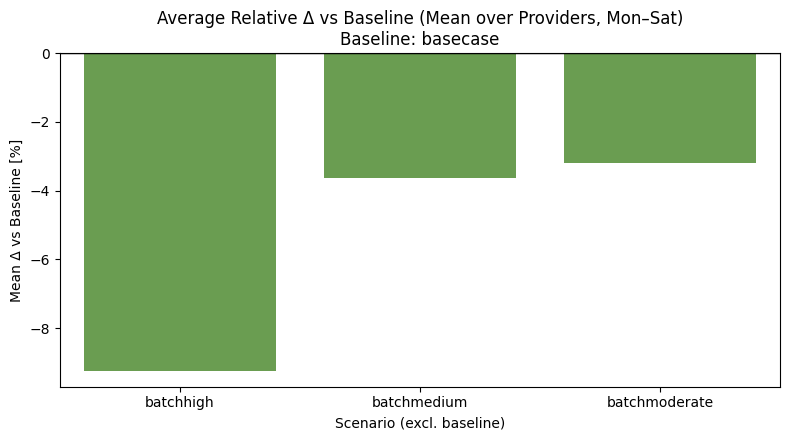

[OK] Saved C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed\plot_rel_total_delta_total_cost_vs_baseline.png


In [8]:
# Provider delta vs baseline (absolute + relative cumulative Mon–Sat total cost)
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as _dt

# --- Preconditions ---
if 'df_all' not in globals() or df_all is None or len(df_all) == 0:
    raise RuntimeError("df_all is empty or not loaded. Run the loader cell above.")

work = df_all.copy()

# --- Ensure required columns ---
if 'vehicle_cost' not in work.columns:
    raise RuntimeError("Required column 'vehicle_cost' missing in df_all.")
work['vehicle_cost'] = pd.to_numeric(work['vehicle_cost'], errors='coerce').fillna(0.0)

if 'run_name' not in work.columns:
    raise RuntimeError("'run_name' missing in df_all; ensure loader added it.")
work['scenario'] = work['run_name'].str.split('_').str[0]

# --- Provider detection ---
provider_col = next((c for c in ['provider','logisticProvider','carrier_provider'] if c in work.columns), None)
if provider_col is not None:
    work['provider'] = work[provider_col].astype(str)
else:
    carrier_candidates = ['carrierID','carrierId','carrier_id','carrier','carrier_id_str']
    carrier_col = next((c for c in carrier_candidates if c in work.columns), None)
    if carrier_col is None:
        raise RuntimeError("No provider/carrier column found; expected one of provider/logisticProvider/carrier_provider or carrierID/carrier_id/carrier.")
    work['provider'] = work[carrier_col].map(getProviderFromID)

# --- Weekday parsing from run_name ---
def _extract_day(run):
    parts = str(run).split('_')
    return parts[1] if len(parts) >= 3 and parts[1].isdigit() and len(parts[1]) == 8 else None

work['day_token'] = work['run_name'].map(_extract_day)

weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
def _weekday_label(day_token):
    try:
        d = _dt.datetime.strptime(day_token, '%d%m%Y').date()
        return ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][d.weekday()]
    except Exception:
        return None

work['weekday'] = work['day_token'].map(_weekday_label)
work = work[work['weekday'].isin(weekday_order)].copy()
work['weekday'] = pd.Categorical(work['weekday'], categories=weekday_order, ordered=True)

# --- Aggregate daily cost per provider/scenario/weekday ---
cost_daily = (work.groupby(['provider','scenario','weekday'], as_index=False)['vehicle_cost']
                 .sum().rename(columns={'vehicle_cost':'total_cost'}))

cost_daily = cost_daily.sort_values(['provider','scenario','weekday'])
cost_daily['cum_total_cost'] = (cost_daily
                                .groupby(['provider','scenario'], group_keys=False)['total_cost']
                                .cumsum())

# --- Take last weekday (Saturday) per provider/scenario ---
last_rows = (cost_daily
             .sort_values(['provider','scenario','weekday'])
             .groupby(['provider','scenario'], as_index=False)
             .tail(1))

# --- Detect baseline ---
scenarios = sorted(last_rows['scenario'].astype(str).unique())
def detect_baseline(cands):
    keys = ['baseline','base','bau','ref','reference','statusquo','status_quo','status-quo','basis','default']
    for k in keys:
        for s in cands:
            if k in s.lower():
                return s
    return None

BASELINE_SCENARIO = detect_baseline(scenarios)
if BASELINE_SCENARIO is None:
    BASELINE_SCENARIO = scenarios[0]
    print(f"[WARN] No explicit baseline scenario found. Using '{BASELINE_SCENARIO}' as baseline.")
else:
    print(f"[INFO] Baseline scenario detected: '{BASELINE_SCENARIO}'")

# --- Compute deltas vs baseline ---
base_map = (last_rows[last_rows['scenario'] == BASELINE_SCENARIO]
            .set_index('provider')['cum_total_cost'])

final = last_rows.copy()
final['baseline_total'] = final['provider'].map(base_map)
final['delta_vs_baseline'] = final['cum_total_cost'] - final['baseline_total']
final['rel_delta_vs_baseline'] = np.where(
    final['baseline_total'] != 0,
    (final['cum_total_cost'] / final['baseline_total'] - 1.0) * 100.0,
    np.nan
)

# --- Drop baseline from comparisons ---
final_nonbase = final[final['scenario'] != BASELINE_SCENARIO].copy()

# --- Save per-provider absolute & relative deltas ---
out_csv_provider = os.path.join(OUTPUT_BASE, 'delta_total_cost_vs_baseline_by_provider.csv')
final_nonbase[['provider','scenario','cum_total_cost','baseline_total',
               'delta_vs_baseline','rel_delta_vs_baseline']].to_csv(out_csv_provider, index=False)
print(f"[OK] Saved {out_csv_provider}")

# --- Plot: absolute Δ vs baseline ---
plt.figure(figsize=(10,5.5))
sns.barplot(data=final_nonbase.sort_values(['provider','scenario']),
            x='provider', y='delta_vs_baseline', hue='scenario')
plt.axhline(0, color='black', linewidth=1)
plt.title(f"Cumulative Total Cost Δ vs Baseline by Provider (Mon–Sat)\nBaseline: {BASELINE_SCENARIO}")
plt.ylabel('Δ Total Cost vs Baseline [€]')
plt.xlabel('Provider')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
fig_provider_abs = os.path.join(OUTPUT_BASE, 'plot_delta_total_cost_vs_baseline_by_provider.png')
plt.savefig(fig_provider_abs, dpi=150)
plt.show()
print(f"[OK] Saved {fig_provider_abs}")

# --- Plot: relative Δ vs baseline [%] ---
plt.figure(figsize=(10,5.5))
sns.barplot(data=final_nonbase.sort_values(['provider','scenario']),
            x='provider', y='rel_delta_vs_baseline', hue='scenario')
plt.axhline(0, color='black', linewidth=1)
plt.title(f"Cumulative Total Cost Δ vs Baseline by Provider (Mon–Sat)\nRelative change [%], Baseline: {BASELINE_SCENARIO}")
plt.ylabel('Δ Total Cost vs Baseline [%]')
plt.xlabel('Provider')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
fig_provider_rel = os.path.join(OUTPUT_BASE, 'plot_rel_delta_total_cost_vs_baseline_by_provider.png')
plt.savefig(fig_provider_rel, dpi=150)
plt.show()
print(f"[OK] Saved {fig_provider_rel}")

# --- Aggregate overall deltas across providers per scenario ---
overall = (final_nonbase.groupby('scenario', as_index=False)
           .agg(sum_delta_vs_baseline=('delta_vs_baseline','sum'),
                mean_rel_delta_vs_baseline=('rel_delta_vs_baseline','mean')))

out_csv_overall = os.path.join(OUTPUT_BASE, 'total_delta_total_cost_vs_baseline.csv')
overall.to_csv(out_csv_overall, index=False)
print(f"[OK] Saved {out_csv_overall}")

# --- Plot: total absolute Δ ---
plt.figure(figsize=(8,4.5))
sns.barplot(data=overall.sort_values('scenario'),
            x='scenario', y='sum_delta_vs_baseline', color='#4477aa')
plt.axhline(0, color='black', linewidth=1)
plt.title(f"Total Δ vs Baseline (Sum over Providers, Mon–Sat)\nBaseline: {BASELINE_SCENARIO}")
plt.ylabel('Total Δ vs Baseline [€]')
plt.xlabel('Scenario (excl. baseline)')
plt.tight_layout()
fig_overall_abs = os.path.join(OUTPUT_BASE, 'plot_total_delta_total_cost_vs_baseline.png')
plt.savefig(fig_overall_abs, dpi=150)
plt.show()
print(f"[OK] Saved {fig_overall_abs}")

# --- Plot: total relative Δ [%] ---
plt.figure(figsize=(8,4.5))
sns.barplot(data=overall.sort_values('scenario'),
            x='scenario', y='mean_rel_delta_vs_baseline', color='#66aa44')
plt.axhline(0, color='black', linewidth=1)
plt.title(f"Average Relative Δ vs Baseline (Mean over Providers, Mon–Sat)\nBaseline: {BASELINE_SCENARIO}")
plt.ylabel('Mean Δ vs Baseline [%]')
plt.xlabel('Scenario (excl. baseline)')
plt.tight_layout()
fig_overall_rel = os.path.join(OUTPUT_BASE, 'plot_rel_total_delta_total_cost_vs_baseline.png')
plt.savefig(fig_overall_rel, dpi=150)
plt.show()
print(f"[OK] Saved {fig_overall_rel}")
